# Used Car Price Prediction

## Linear Regression Model

**Course:** Machine Learning / FDM  
**Stage:** Stage 6, Stage 7 and Stage 8  
**Model:** Linear Regression  
**Problem Type:** Supervised Regression

## 1. Introduction

This notebook presents the implementation and evaluation of the Linear Regression
algorithm for the Used Car Price Prediction project.

The objective is to predict used vehicle prices using information such as vehicle
age, mileage, mileage per year and other selected features.

Linear Regression is implemented as a baseline regression model and is evaluated
using MAE, RMSE and R². Five-fold cross-validation is used to assess model
performance during development.

Hyperparameter tuning and additional modelling experiments are performed as part
of Stage 7.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_validate, GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

Training data shape: (3206, 14)
Testing data shape : (802, 14)


In [3]:
print("Training Data:")
display(train_df.head())

print("\nTesting Data:")
display(test_df.head())

Training Data:


,car_age,milage,mileage_per_year,is_luxury_brand,is_manual,is_clean_title,has_accident,fuel_E85 Flex Fuel,fuel_Electric,fuel_Gasoline,fuel_Hybrid,fuel_Other,fuel_Plug-In Hybrid,log_price
0,0.897401,0.763924,0.040503,1,0,1,0,0,0,1,0,0,0,9.465060
1,1.881127,-0.016871,-0.885280,0,0,1,0,0,0,1,0,0,0,8.682877
2,0.241584,2.112052,2.143746,0,0,1,1,0,0,0,0,0,0,10.609082
3,1.389264,0.650551,-0.310325,1,1,1,0,0,0,1,0,0,0,10.308819
4,-0.906095,0.141010,2.636934,1,0,1,0,0,0,1,0,0,0,11.289669



Testing Data:


,car_age,milage,mileage_per_year,is_luxury_brand,is_manual,is_clean_title,has_accident,fuel_E85 Flex Fuel,fuel_Electric,fuel_Gasoline,fuel_Hybrid,fuel_Other,fuel_Plug-In Hybrid,log_price
0,-0.742141,-0.462128,0.306550,0,0,1,0,0,0,1,0,0,0,10.389026
1,-0.086324,-0.293688,-0.310648,1,0,1,1,0,0,1,0,0,0,9.975855
2,-0.250278,0.181829,0.581267,1,0,1,0,0,0,1,0,0,0,9.903538
3,-0.578187,-0.785175,-0.673122,1,0,1,0,0,0,1,0,0,0,10.491274
4,0.897401,-0.179615,-0.732836,0,0,1,0,0,0,1,0,0,0,9.099521


In [4]:
print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training shape: (3206, 14)
Testing shape : (802, 14)

Training columns:
['car_age', 'milage', 'mileage_per_year', 'is_luxury_brand', 'is_manual', 'is_clean_title', 'has_accident', 'fuel_E85 Flex Fuel', 'fuel_Electric', 'fuel_Gasoline', 'fuel_Hybrid', 'fuel_Other', 'fuel_Plug-In Hybrid', 'log_price']

Testing columns:
['car_age', 'milage', 'mileage_per_year', 'is_luxury_brand', 'is_manual', 'is_clean_title', 'has_accident', 'fuel_E85 Flex Fuel', 'fuel_Electric', 'fuel_Gasoline', 'fuel_Hybrid', 'fuel_Other', 'fuel_Plug-In Hybrid', 'log_price']


In [5]:
X_train = train_df.drop(columns=["log_price"])
y_train = train_df["log_price"]

X_test = test_df.drop(columns=["log_price"])
y_test = test_df["log_price"]

In [6]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (3206, 13)
y_train: (3206,)
X_test : (802, 13)
y_test : (802,)


In [7]:
print("Training missing values:")
print(X_train.isnull().sum().sum())

print("\nTesting missing values:")
print(X_test.isnull().sum().sum())

Training missing values:
0

Testing missing values:
0


In [8]:
print(
    "Feature columns identical:",
    list(X_train.columns) == list(X_test.columns)
)

Feature columns identical: True


# Stage 6 – Model Development

## 6.1 Linear Regression baseline

Linear Regression is implemented as one of the selected regression algorithms
for the Used Car Price Prediction problem.

The model is trained using the training dataset and evaluated using MAE,
RMSE and R². Five-fold cross-validation is performed using only the training
data, while the separate test dataset is reserved for final evaluation.

In [9]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6.2 Model Predictions

In [10]:
y_pred = lr_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[10.55490265 10.50128576 10.45817497 10.96031935  9.97975926  9.66120812
 10.13241487  9.78526831 10.00523399 11.10542176]


## 6.3 Model Evaluation

The Linear Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

MAE and RMSE measure prediction error, while R² measures the proportion
of variance in the target variable explained by the model.

In [11]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Test Results ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

=== Linear Regression Test Results ===
MAE  : 0.4219
RMSE : 0.5414
R²   : 0.5993


## 6.4 Five-Fold Cross-Validation

Five-fold cross-validation is performed using only the training data.
The test set is kept separate and is not used during model development.

This provides a more reliable estimate of model performance across
different subsets of the training data.

In [12]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    LinearRegression(),
    X_train,
    y_train,
    cv=kfold,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=False
)

In [13]:
cv_mae = -cv_results["test_MAE"]
cv_rmse = -cv_results["test_RMSE"]
cv_r2 = cv_results["test_R2"]

print("=== 5-Fold Cross-Validation Results ===")

print(f"Mean CV MAE  : {cv_mae.mean():.4f}")
print(f"Mean CV RMSE : {cv_rmse.mean():.4f}")
print(f"Mean CV R²   : {cv_r2.mean():.4f}")

=== 5-Fold Cross-Validation Results ===
Mean CV MAE  : 0.4018
Mean CV RMSE : 0.5272
Mean CV R²   : 0.6099


In [14]:
cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MAE": cv_mae,
    "RMSE": cv_rmse,
    "R2": cv_r2
})

cv_table

,Fold,MAE,RMSE,R2
0,1,0.391771,0.502651,0.625976
1,2,0.413172,0.543940,0.587580
2,3,0.414106,0.540589,0.621100
3,4,0.396991,0.529184,0.599424
4,5,0.392776,0.519804,0.615211


## 6.5 Linear Regression Experiment Results

In [15]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "CV MAE": [cv_mae.mean()],
    "CV RMSE": [cv_rmse.mean()],
    "CV R2": [cv_r2.mean()],
    "Test MAE": [mae],
    "Test RMSE": [rmse],
    "Test R2": [r2]
})

lr_results

,Model,CV MAE,CV RMSE,CV R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.401763,0.527234,0.609858,0.421945,0.541358,0.599293


# Stage 7 – Model Optimization

## 7.1 Hyperparameter Tuning

Grid Search with five-fold cross-validation is used to investigate
different Linear Regression configurations.

The independent test dataset remains untouched during the tuning process.

In [17]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [False, True]
}

print("Parameter combinations:")
print(param_grid)

grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

Parameter combinations:
{'fit_intercept': [True, False], 'positive': [False, True]}


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [False, True]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of 

In [18]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'fit_intercept': True, 'positive': False}

Best Cross-Validation RMSE:
0.5266117405994722


In [19]:
tuned_lr = grid_search.best_estimator_

print("Best Linear Regression Model:")
print(tuned_lr)

Best Linear Regression Model:
LinearRegression()


In [ ]:
tuned_pred = tuned_lr.predict(X_test)


tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("=== Tuned Linear Regression Test Results ===")

print(f"MAE  : {tuned_mae:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned model predictions generated.
=== Tuned Linear Regression Test Results ===
MAE  : 0.4219
RMSE : 0.5414
R²   : 0.5993


## 7.2 Baseline vs Tuned Linear Regression

In [30]:
baseline_vs_tuned = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Tuned Linear Regression"
    ],
    "MAE": [
        mae,
        tuned_mae
    ],
    "RMSE": [
        rmse,
        tuned_rmse
    ],
    "R2": [
        r2,
        tuned_r2
    ]
})

baseline_vs_tuned

,Model,MAE,RMSE,R2
0,Baseline Linear Regression,0.421945,0.541358,0.599293
1,Tuned Linear Regression,0.421945,0.541358,0.599293


In [31]:
print("RMSE improvement:")

if tuned_rmse < rmse:
    print("Tuning improved RMSE.")
elif tuned_rmse > rmse:
    print("Tuning increased RMSE.")
else:
    print("Tuning produced the same RMSE.")

RMSE improvement:
Tuning produced the same RMSE.


In [32]:
print("\nR² comparison:")

if tuned_r2 > r2:
    print("Tuning improved R².")
elif tuned_r2 < r2:
    print("Tuning decreased R².")
else:
    print("Tuning produced the same R².")


R² comparison:
Tuning produced the same R².


## 7.2 Actual vs Predicted Values

In [ ]:
prediction_comparison = pd.DataFrame({
    "Actual_log_price": y_test.values,
    "Predicted_log_price": tuned_pred
})

display(prediction_comparison.head(10)) 

,Actual_log_price,Predicted_log_price
0,10.389026,10.554903
1,9.975855,10.501286
2,9.903538,10.458175
3,10.491274,10.960319
4,9.099521,9.979759
5,9.680406,9.661208
6,9.012011,10.132415
7,9.532496,9.785268
8,9.510519,10.005234
9,10.434145,11.105422


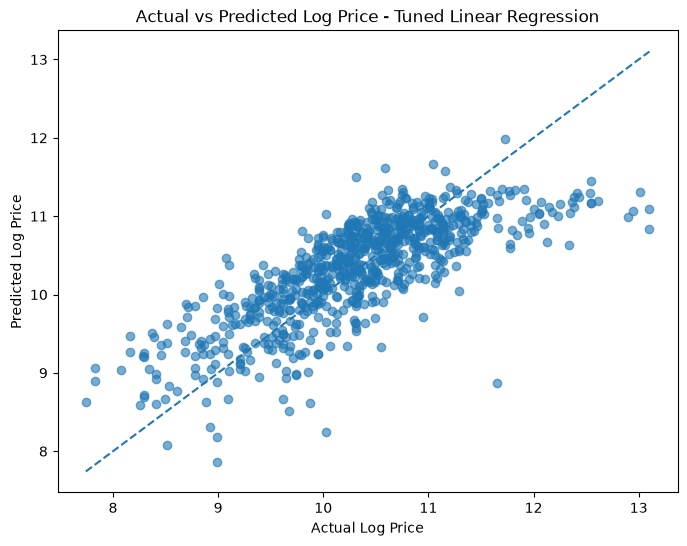

In [34]:
# ============================================
# Actual vs Predicted Plot
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), tuned_pred.min())
max_value = max(y_test.max(), tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Log Price - Tuned Linear Regression")

plt.show()

## 7.3  Residual Analysis

## Residual = Actual − Predicted.


In [35]:
# ============================================
# Residual Analysis
# ============================================

residuals = y_test - tuned_pred

print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())

Residual Mean: -0.020748762902011938
Residual Standard Deviation: 0.5412974659219572


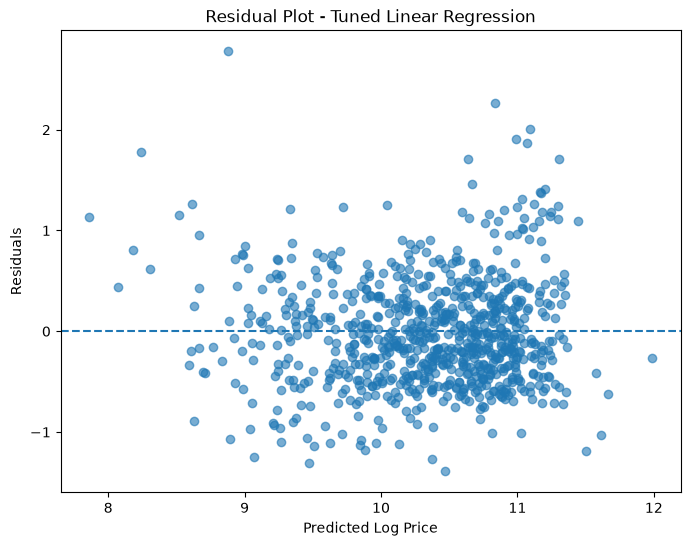

In [36]:
# ============================================
# Residual Plot
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    tuned_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Tuned Linear Regression")

plt.show()

## 7.2 Feature Engineering and Selection

The training and testing datasets used in this stage were produced during
the previous preprocessing and feature engineering stages.

The selected features include vehicle age, mileage, mileage per year,
luxury-brand indicator, transmission indicator, accident history,
clean-title indicator and encoded fuel-type variables.

These prepared features are used consistently across the four models
to ensure a fair model comparison.

## 7.3 Observations

The baseline and tuned Linear Regression models are compared using MAE,
RMSE and R².

Lower MAE and RMSE indicate lower prediction errors, while a higher R²
indicates that a greater proportion of variation in the target is explained.

The tuning results are interpreted based on the cross-validation and
independent test-set results.

In [28]:
# ============================================
# Stage 8: Final Linear Regression Results
# ============================================

final_lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "CV MAE": [cv_mae.mean()],
    "CV RMSE": [cv_rmse.mean()],
    "CV R2": [cv_r2.mean()],
    "Test MAE": [tuned_mae],
    "Test RMSE": [tuned_rmse],
    "Test R2": [tuned_r2]
})

display(final_lr_results)

,Model,CV MAE,CV RMSE,CV R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.401763,0.527234,0.609858,0.421945,0.541358,0.599293


In [29]:
# ============================================
# Save Linear Regression Results
# ============================================

final_lr_results.to_csv(
    "linear_regression_results.csv",
    index=False
)

baseline_vs_tuned.to_csv(
    "linear_regression_baseline_vs_tuned.csv",
    index=False
)

cv_table.to_csv(
    "linear_regression_cv_results.csv",
    index=False
)

print("Result files saved successfully.")

Result files saved successfully.
